## load libraries

In [4]:
pip install transformers torch pandas


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Load the Model

In [5]:
from transformers import AutoTokenizer, AutoModel

name = "emilyalsentzer/Bio_ClinicalBERT" # high reviews.
tokenizer = AutoTokenizer.from_pretrained(name)
model = AutoModel.from_pretrained(name)

print("Loaded ClinicalBERT")

/Users/shrikar/.pyenv/versions/3.13.1/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2737.50it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.Layer

Loaded ClinicalBERT


## Sample Row View

In [6]:
sample = "Lupus, Essential Thrombocythemia, Ovarian Cancer"
inputs = tokenizer(sample, return_tensors="pt") #what does pt mean? Print?

outputs = model(**inputs) # feed inputs to model.
sig = outputs.last_hidden_state.mean(dim=1) # each patient looks like [1, number of conditions, 768]

print(f"Original Text: {sample}")
print(f"New Text Shape: {sig.shape}") #embedding -> will look different between patients with varying conditions.

Original Text: Lupus, Essential Thrombocythemia, Ovarian Cancer
New Text Shape: torch.Size([1, 768])


## Load CSV

In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv("chest_pain_patients.csv")
print(df.head())
print(df.columns.to_list())

   Age     Sex      Race      Ethnicity   WBC   Hgb    Plt     Na    K     Cl  \
0   47  Female  Hispanic       Hispanic   6.7  15.3  222.7  140.0  3.7  104.9   
1   54    Male     Other   Non-Hispanic   9.7  13.9  235.1  144.5  3.4   98.6   
2   66    Male     Black  Not Specified  11.3  17.2  329.7  138.5  3.7  106.7   
3   65  Female     White         Latino  11.3  14.0  247.8  144.3  4.2  104.6   
4   88  Female  Hispanic         Latino  11.4  16.6  121.0  137.6  4.6   98.9   

   ...  Glucose  Troponin                EKG                        CXR  \
0  ...    139.9      0.01             Normal             Hyperinflation   
1  ...    128.0      0.03  Sinus Bradycardia         Pulmonary Fibrosis   
2  ...    202.1      0.01        Low Voltage  Interstitial Lung Disease   
3  ...    170.0      0.01                WPW  Interstitial Lung Disease   
4  ...    134.1      0.01                SVT           Pulmonary Nodule   

                                Past_Medical_History  \
0  Lup

## Fill in Missing Data with None values.

In [8]:
df = df.fillna("N/A") # reassign df to one without null data.
print(df.isnull().sum())

Age                       0
Sex                       0
Race                      0
Ethnicity                 0
WBC                       0
Hgb                       0
Plt                       0
Na                        0
K                         0
Cl                        0
CO2                       0
BUN                       0
Cr                        0
Glucose                   0
Troponin                  0
EKG                       0
CXR                       0
Past_Medical_History      0
Outpatient_Medications    0
Allergies                 0
Cath_Report               0
Echo_Report               0
CTPE_Report               0
dtype: int64


## Feed unstructured (text) cols to ClinicalBERT

In [9]:
import torch
from tqdm import tqdm

# Create a single narrative column for ClinicalBERT to read - include all of the string columns.
text_columns = ['EKG', 'CXR', 'Past_Medical_History', 'Outpatient_Medications', 'Allergies', 'Cath_Report', 'Echo_Report', 'CTPE_Report']

# We join them with a separator so BERT knows where one section ends and another begins
df['full_narrative'] = df[text_columns].astype(str).agg(' | '.join, axis=1)

print("Sample Narrative:", df['full_narrative'].iloc[0][:100] + "...")

def embeddings(cols, batch_size=16):
    model.eval()

    all_embeddings = []

    for i in tqdm(range(0, len(cols), batch_size)): #step size is batch_size
        batch_txt = cols[i:i+batch_size]

        inputs = tokenizer(batch_txt, padding=True, truncation=True, max_length=512, return_tensors="pt")
        with torch.no_grad():
            outputs = model(**inputs) #embeddings.
        
        # what is this doing?
        mask = inputs["attention_mask"].unsqueeze(-1).expand(outputs.last_hidden_state.size()).float() #what does this do?
        sum_embeddings = torch.sum(outputs.last_hidden_state * mask, 1) #
        sum_mask = torch.clamp(mask.sum(1), min=1e-9)
        
        batch_embeddings = (sum_embeddings / sum_mask).numpy()
        all_embeddings.append(batch_embeddings)

    return np.vstack(all_embeddings)

vectors = embeddings(df["full_narrative"].tolist())
print(f"Generated a {vectors.shape} matrix (should be 100 x 768)")

Sample Narrative: Normal | Hyperinflation | Lupus, Essential Thrombocythemia, Ovarian Cancer, COPD, Melanoma, Hypothyr...


100%|██████████| 7/7 [00:01<00:00,  3.60it/s]

Generated a (100, 768) matrix (should be 100 x 768)


## Convert into BERT Table

In [10]:
# naming each column
bert_df = pd.DataFrame(vectors, columns=[f"bert_{i}" for i in range(768)])
bert_df.index = df.index # making sure indices match so data can be mapped.
print(bert_df.head())


     bert_0    bert_1    bert_2    bert_3    bert_4    bert_5    bert_6  \
0 -0.291258 -0.063768 -0.029395  0.238001 -0.240729 -0.007191 -0.013798   
1 -0.218181  0.016707 -0.035698  0.172803 -0.181630  0.138012  0.096852   
2 -0.179852 -0.162273 -0.050466  0.228497 -0.154533  0.000480 -0.115775   
3 -0.098176 -0.037949 -0.072045  0.306198 -0.236206  0.089841  0.137116   
4 -0.071543 -0.169219  0.019924  0.241565 -0.085981 -0.025662 -0.022377   

     bert_7    bert_8    bert_9  ...  bert_758  bert_759  bert_760  bert_761  \
0  0.213774  0.263128 -0.053252  ... -0.194566 -0.160087 -0.273217  0.036070   
1  0.290225  0.246862  0.038341  ... -0.159814 -0.252117 -0.234133  0.092047   
2  0.145912  0.277234 -0.127086  ... -0.225635 -0.159737 -0.228153  0.033559   
3  0.230832  0.279044  0.029250  ... -0.220698 -0.327179 -0.293225 -0.020954   
4  0.240804  0.296156 -0.094524  ... -0.216846 -0.221257 -0.260663  0.049525   

   bert_762  bert_763  bert_764  bert_765  bert_766  bert_767  
0  0

## Scaling + Merge DataFrames Together

In [11]:
pip install scikit-learn


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [12]:
from sklearn.preprocessing import StandardScaler

# apply scaler to numeric columns - not to the whole merged dataframe.
numeric_data = ['WBC', 'Hgb', 'Plt', 'Na', 'K', 'Cl', 'CO2', 'BUN', 'Cr', 'Glucose', 'Troponin']
scaler = StandardScaler()
df_scaled_lab_data = pd.DataFrame(scaler.fit_transform(df[numeric_data]), columns=numeric_data)

# concatenate result.
master_df = pd.concat([df_scaled_lab_data, bert_df], axis=1)
print(master_df.head())


        WBC       Hgb       Plt        Na         K        Cl       CO2  \
0 -0.464787  0.567400 -0.297251 -0.027985 -0.837172  0.257521  1.118475   
1  0.744547 -0.067073 -0.150711  1.526761 -1.409272 -1.648920  0.848457   
2  1.389525  1.428469  0.967245 -0.546234 -0.837172  0.802218  1.238483   
3  1.389525 -0.021753 -0.000626  1.457661  0.116327  0.166738 -0.771652   
4  1.429836  1.156553 -1.499113 -0.857183  0.879126 -1.558137 -1.671712   

        BUN        Cr   Glucose  ...  bert_758  bert_759  bert_760  bert_761  \
0  0.164395  0.791128 -0.346074  ... -0.194566 -0.160087 -0.273217  0.036070   
1  1.653255  0.040057 -0.577230  ... -0.159814 -0.252117 -0.234133  0.092047   
2 -0.331892  1.792556  0.862155  ... -0.225635 -0.159737 -0.228153  0.033559   
3  0.247109 -0.961371  0.238616  ... -0.220698 -0.327179 -0.293225 -0.020954   
4 -1.138357 -0.711014 -0.458739  ... -0.216846 -0.221257 -0.260663  0.049525   

   bert_762  bert_763  bert_764  bert_765  bert_766  bert_767  
0  0

## Cosine Similarity


In [13]:
from sklearn.metrics.pairwise import cosine_similarity

# Create a 'worst-case scenario' description
crisis_text = "Critical clinical instability, multi-system organ failure, high mortality risk, severe comorbidities, emergency intervention required."

# Turn it into a 768-vector using your BERT function
crisis_vector = embeddings([crisis_text]).reshape(1, -1)
# print(crisis_vector)

# cosine similarity
df["severity"] = cosine_similarity(bert_df, crisis_vector) # compares each column of bert with example vector above.
print(f"Severity score for first patient: {df['severity'].iloc[45]:.4f}")

# this simply takes into account the bert data - not the lab data.
# account for lab data by choosing a median value, then graphing scaled values against it.



100%|██████████| 1/1 [00:00<00:00, 39.55it/s]

Severity score for first patient: 0.8022



/Users/shrikar/.pyenv/versions/3.13.1/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/shrikar/.pyenv/versions/3.13.1/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/shrikar/.pyenv/versions/3.13.1/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


## Graph Showing ClinicalBERT scores vs lab data.

### 2D Risk Stratification Matrix


#### X-Axis
- Shows how ClinicalBERT analyzed the past medical history, EKG, allergies, outpatient medications to give a score for the patient.
- ClinicalBERT relies on text data, so by this data alone, it can get patient information wrong.
    - For example, a patient could have a severe medical history, but be fine today (according to lab results on y-axis)

#### Y-Axis
- Shows an analysis of the lab (numerical) data (not using ClinicalBERT).
- A patient could have bad lab results, but ClinicalBERT's analysis (x-axis) could say they have a non-severe history, allergies, and so on.

0      50.40
1      65.22
2     145.30
3      35.40
4     176.20
       ...  
95    173.00
96    121.40
97    213.40
98    164.80
99     97.20
Length: 100, dtype: float64
0     0.069029
1     0.137230
2     0.505752
3     0.000000
4     0.647952
        ...   
95    0.633226
96    0.395766
97    0.819144
98    0.595490
99    0.284399
Name: lab_score, Length: 100, dtype: float64
0     0.160431
1     0.629791
2     0.578161
3     0.549261
4     0.292549
        ...   
95    0.409410
96    0.676880
97    0.642582
98    0.356501
99    0.049829
Name: text_score, Length: 100, dtype: float32


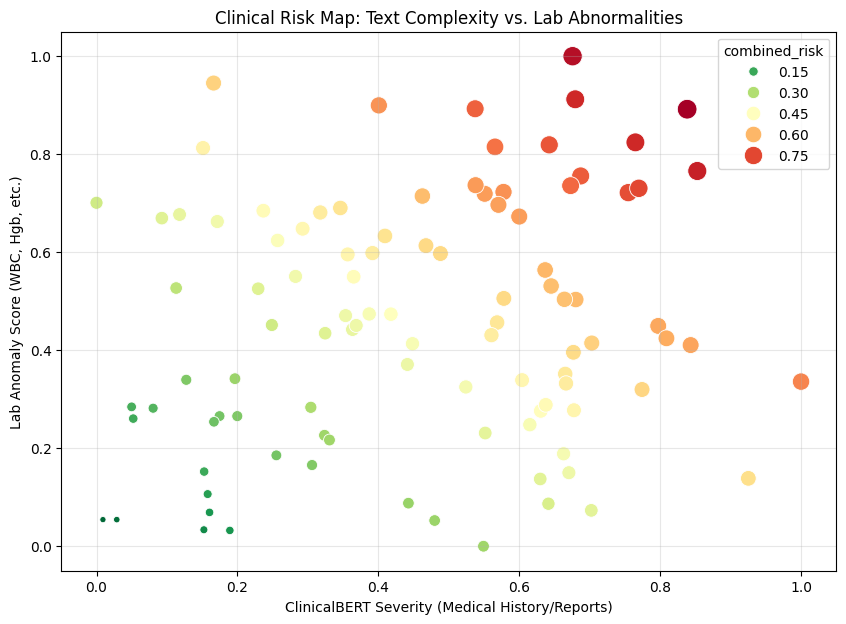

In [14]:
import seaborn as sb
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

lab_distances = np.abs(df[numeric_data] - df[numeric_data].median()).sum(axis=1) # subtract median and add distances together to get score per patient.
print(lab_distances) #notice that some patients are really far from the median - 4, 95 - 99, etc.

# scale the lab distances (above) with bert scores (decimals)
scaler = MinMaxScaler()


df["lab_score"] = scaler.fit_transform(lab_distances.values.reshape(-1, 1)) # scaler wants a matrix, we turn lab_distances (which is an array) into a 1x1 matrix.
print(df["lab_score"]) # our regular lab data.

df["text_score"] = scaler.fit_transform(df["severity"].values.reshape(-1, 1))
print(df["text_score"]) # what clinicalBERT gave for those same patients from the text data alone.

df["combined_risk"] = (df["text_score"] + df["lab_score"])/2

# graph the scaled scores against each other.
plt.figure(figsize=(10, 7))
sb.scatterplot(
    data=df, 
    x='text_score', # columns.
    y='lab_score', 
    size= "combined_risk", 
    hue= "combined_risk",
    palette='RdYlGn_r', # Red for high risk, Green for low
    sizes=(20, 200)
)

plt.title('Clinical Risk Map: Text Complexity vs. Lab Abnormalities')
plt.xlabel('ClinicalBERT Severity (Medical History/Reports)')
plt.ylabel('Lab Anomaly Score (WBC, Hgb, etc.)')
plt.grid(True, alpha=0.3) #alpha changes opacity of data point.

In [15]:
%pip install nbformat
%pip install --upgrade nbformat



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [16]:
%pip install -q -U google-genai 


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [17]:
%pip install python-dotenv


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [18]:
# installing AI platform to interact with account.
%pip install google-cloud-aiplatform


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [45]:
import os
from dotenv import load_dotenv
from google import genai
from google.genai import types

load_dotenv()

# use vertex client.
client = genai.Client(vertexai=True, project=os.getenv('GOOGLE_CLOUD_PROJECT'))

def generate_summary(row):
    # take each db row, and generate summary based on data.
    prompt = f"""
    Acting as a medical analyst, summarize this patient:
    - History: {row['Past_Medical_History']}
    - Outpatient medications: {row['Outpatient_Medications']}
    - Labs: Troponin {row['Troponin']}, EKG {row['EKG']}, Potassium {row['K']}, Hemoglobin {row['Hgb']}, Creatinine {row['Cr']}
    - BERT Severity Score: {row['text_score']:.2f}
    - Lab Anomaly Score: {row['lab_score']:.2f}
    
    Do not exceed 50 words. Clearly explain why this patient is ranked at a risk level of {row['combined_risk']:.2f}. No headings or formatted text.
    """

    # return the response.
    return client.models.generate_content(
        model='gemini-2.5-flash',
        contents=prompt
    ).text.strip()

df['AI_Summary'] = df.head(20).apply(generate_summary, axis=1)



In [46]:
## Second Graph: using Plotly for interactivity instead
# can hover per data point and see patient data.

import plotly.express as px
import textwrap

# create a column for hover text per patient.
df["summary"] = df["full_narrative"].str.slice(0, 75)
df['mini_pmh'] = df['Past_Medical_History'].str.slice(0, 50)
df['mini_opm'] = df['Outpatient_Medications'].str[:50] 

# wrap all the AI summaries into neat boxes.
def wrap_summary(text):
    if not isinstance(text, str):
        return ""
    else:
        wrapped = textwrap.wrap(text, width=50)
        return "<br>".join(wrapped)

df['Wrapped_AI_Summary'] = df['AI_Summary'].apply(wrap_summary)

# build the plot
fig = px.scatter(
    data_frame=df,
    x='text_score',
    y='lab_score',
    color='combined_risk',
    size='combined_risk',
    hover_name=df.index,
    hover_data={
        'combined_risk':':.3f',
        'text_score': ':.3f',
        'lab_score': ':.3f',
        'Age':True,
        'WBC': True,
        'Wrapped_AI_Summary': True
    },
    title='Clinical Risk Map: Text Complexity vs. Lab Abnormalities',   
    width=1300,
    height=1000
)


fig.show()





## Part 2

### Reformatting CSV Data - including multiple patients with rows.

In [24]:
# include new csv file: 
expanded_df = pd.read_csv("expanded_patient_data.csv")
print(expanded_df.head)

<bound method NDFrame.head of      Age     Sex      Race      Ethnicity    WBC    Hgb     Plt      Na     K  \
0     68  Female     Other  Not Specified   5.79  12.19  292.85  128.95  4.27   
1     34  Female     White         Latino   6.60  15.30  218.20  144.50  4.20   
2     35  Female     Other  Not Specified  10.20  11.60  333.10  137.80  3.60   
3     52    Male     Black         Latino   9.47  11.17  186.30  130.27  4.66   
4     33    Male     White  Not Specified   3.80  11.60  178.00  143.30  3.60   
..   ...     ...       ...            ...    ...    ...     ...     ...   ...   
169   52    Male  Hispanic       Hispanic   4.03   9.92  179.99  132.99  5.42   
170   35  Female     Other  Not Specified   9.26  12.27  302.01  134.08  3.33   
171   49    Male  Hispanic       Hispanic  11.10  15.80  384.40  144.00  4.20   
172   95    Male     Black   Non-Hispanic   9.98  11.81  118.04  136.85  4.62   
173   21    Male     Asian  Not Specified  10.89  16.68  197.35  145.64  4.97  

### Eliminate Null Cells from New Data

In [25]:
# eliminate any null cells.
expanded_df = expanded_df.fillna("N/A") # reassign df to one without null data.
print(expanded_df.isnull().sum())

# group rows by patient name (want summaries per patient)
patient_groups = expanded_df.groupby('Patient_Name')
print(patient_groups)


Age                       0
Sex                       0
Race                      0
Ethnicity                 0
WBC                       0
Hgb                       0
Plt                       0
Na                        0
K                         0
Cl                        0
CO2                       0
BUN                       0
Cr                        0
Glucose                   0
Troponin                  0
EKG                       0
CXR                       0
Past_Medical_History      0
Outpatient_Medications    0
Allergies                 0
Cath_Report               0
Echo_Report               0
CTPE_Report               0
Patient_Name              0
dtype: int64


### Recreate Embeddings with New Data

In [31]:
# re run lab statistics from before (new BERT df, new lab risk and text risk scores, etc.)
# Create a single narrative column for ClinicalBERT to read - include all of the string columns.
text_columns.append('Patient_Name')

# We join them with a separator so BERT knows where one section ends and another begins
expanded_df['full_narrative'] = expanded_df[text_columns].astype(str).agg(' | '.join, axis=1)

print("Sample Narrative:", expanded_df['full_narrative'].iloc[0][:100] + "...")
new_vectors = embeddings(expanded_df["full_narrative"].tolist())
print(f"Generated a {new_vectors.shape} matrix (should be 174 x 768)")

Sample Narrative: Ventricular Tachycardia | Pulmonary Fibrosis | Wegener's Granulomatosis, Amyloidosis, Anxiety, Bronc...


100%|██████████| 11/11 [00:03<00:00,  3.05it/s]

Generated a (174, 768) matrix (should be 174 x 768)


### Recreate BERT DataFrame

In [37]:
# creating a new bert dataframe.
new_bert_df = pd.DataFrame(new_vectors, columns=[f"bert_{i}" for i in range(768)])
new_bert_df.index = expanded_df.index # making sure indices match so data can be mapped.
print(new_bert_df.head())

# next step - does changing the crisis vector change the statement?
expanded_df["severity"] = cosine_similarity(new_bert_df, crisis_vector) # compares each column of bert with example vector above.
print(f"Severity score for first patient: {expanded_df['severity'].iloc[45]:.4f}")

     bert_0    bert_1    bert_2    bert_3    bert_4    bert_5    bert_6  \
0 -0.105826 -0.027934 -0.159958  0.086243 -0.126705  0.102470  0.023706   
1 -0.125792 -0.111152  0.043942  0.137497 -0.123121  0.039072  0.033082   
2 -0.129207 -0.127849  0.060104  0.267167 -0.162167  0.082796 -0.048518   
3 -0.165699 -0.049383 -0.136395  0.071948 -0.075020  0.083102  0.068825   
4 -0.149399 -0.027102 -0.008340  0.100707 -0.068968  0.100487 -0.040403   

     bert_7    bert_8    bert_9  ...  bert_758  bert_759  bert_760  bert_761  \
0  0.187624  0.279380  0.138338  ... -0.305498 -0.314726 -0.256364  0.150104   
1  0.185772  0.298289 -0.014462  ... -0.296529 -0.272508 -0.155963 -0.046591   
2  0.259007  0.252878  0.055858  ... -0.219429 -0.166400 -0.239564  0.053629   
3  0.171203  0.263348 -0.022283  ... -0.237958 -0.274703 -0.242401  0.108869   
4  0.086559  0.344118 -0.001000  ... -0.327617 -0.149549 -0.141114 -0.032922   

   bert_762  bert_763  bert_764  bert_765  bert_766  bert_767  
0  0

/Users/shrikar/.pyenv/versions/3.13.1/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning:

divide by zero encountered in matmul

/Users/shrikar/.pyenv/versions/3.13.1/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning:

overflow encountered in matmul

/Users/shrikar/.pyenv/versions/3.13.1/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning:

invalid value encountered in matmul



### Recalculate Lab Scores and Test Scores, along with Combined Risk, per patient group.

In [40]:
new_lab_distances = np.abs(expanded_df[numeric_data] - expanded_df[numeric_data].median()).sum(axis=1) # subtract median and add distances together to get score per patient.
print(lab_distances) #notice that some patients are really far from the median - 4, 95 - 99, etc.
# print("Median: ", expanded_df[numeric_data].median())

# scale the lab distances (above) with bert scores (decimals)
scaler = MinMaxScaler()


expanded_df["lab_score"] = scaler.fit_transform(new_lab_distances.values.reshape(-1, 1)) # scaler wants a matrix, we turn lab_distances (which is an array) into a 1x1 matrix.
print(expanded_df["lab_score"]) # our regular lab data.

expanded_df["text_score"] = scaler.fit_transform(expanded_df["severity"].values.reshape(-1, 1))
print(expanded_df["text_score"]) # what clinicalBERT gave for those same patients from the text data alone.

expanded_df["combined_risk"] = (expanded_df["text_score"] + expanded_df["lab_score"])/2

0      50.40
1      65.22
2     145.30
3      35.40
4     176.20
       ...  
95    173.00
96    121.40
97    213.40
98    164.80
99     97.20
Length: 100, dtype: float64
0      0.471023
1      0.159088
2      0.449364
3      0.483137
4      0.595191
         ...   
169    0.300876
170    0.372551
171    0.652824
172    0.840270
173    0.542055
Name: lab_score, Length: 174, dtype: float64
0      0.794302
1      0.402882
2      0.550957
3      0.713322
4      0.214478
         ...   
169    0.313025
170    0.550957
171    0.311930
172    0.792572
173    0.636824
Name: text_score, Length: 174, dtype: float32


### Gather Average Statistics and Lab History per patient.

In [43]:
# aggregate patient data is done.
# now, separate static data (age, sex, race) from dynamic data (lab stats) per patient.

summaries_list = []
for name, group in patient_groups:

    # a patient could have many rows.
    # take the first (or only) row and grab static info.
    static_info = group.iloc[0]

    # most critical labs: WBC, Hgb, Na, K, BUN, Cr, Troponin, and maybe EKG
    # calculate ranges for each one.
    range_k = f"{group['K'].min()} to {group['K'].max()}"
    range_na = f"{group['Na'].min()} to {group['Na'].max()}"
    range_glucose = f"{group['Glucose'].min()} to {group['Glucose'].min()}"
    peak_troponin = group['Troponin'].max()

    # gather risks - lab risks, text risk.
    peak_lab_risk = group['lab_score'].max()
    text_risk_score = group['text_score'].iloc[0] # won't change between many rows, since the text data is the same mostly.



    avg_Cr = group['Cr'].mean()
    avg_CO2 = group['CO2'].mean()
    avg_BUN = group['BUN'].mean()

    lab_history = []

    for i, (idx, row) in enumerate(group.iterrows()): # doing (idx, row) makes a series, and we can index it.
        lab_res = f"Lab {i}: WBC: {row['WBC']}, Hgb: {row['Hgb']}, K: {row['K']}, Glucose: {row['Glucose']}, Troponin: {row['Troponin']}"
        lab_history.append(lab_res)

    summaries_list.append(
        {
            "Patient_Name":name,
            'Age': static_info['Age'],
            'Past_Medical_History': static_info['Past_Medical_History'],
            'Peak Troponin': peak_troponin,
            'Potassium (K) range': range_k,
            'Sodium (Na) Range': range_na,
            "Glucose Range":range_glucose,
            "Average Creatine":round(avg_Cr, 3),
            "Average CO2": round(avg_CO2, 3),
            "Average BUN": round(avg_BUN, 3),
            "Peak_lab_risk": peak_lab_risk,
            "text_severity": text_risk_score,
            'Combined risk': (peak_lab_risk + text_risk_score) / 2, # recalculating these values since there are more rows, and now groups.
            "Lab History": "|".join(lab_history),
            "Visit Count": len(group)
        }
    )

patient_summmary_df = pd.DataFrame(summaries_list)
print(patient_summmary_df.head())
print(patient_summmary_df.shape)
    




         Patient_Name  Age                               Past_Medical_History  \
0  Alexander Anderson   66               Alcohol Use Disorder, Bronchiectasis   
1      Alexander King   47  Lupus, Essential Thrombocythemia, Ovarian Canc...   
2         Amanda Hall   37   Hyperlipidemia, Alport Syndrome, Marfan Syndrome   
3           Amy Gomez   95  Nephrolithiasis, Alport Syndrome, Hypertension...   
4        Anna Sanchez   54  Anxiety, Cushing's Syndrome, Endometriosis, Hy...   

   Peak Troponin Potassium (K) range Sodium (Na) Range     Glucose Range  \
0           0.01          3.4 to 3.4    137.8 to 137.8    118.5 to 118.5   
1           0.01        3.58 to 3.83   132.29 to 140.0  128.66 to 128.66   
2           0.01          4.5 to 4.8  136.09 to 151.46    67.98 to 67.98   
3           0.01        4.17 to 4.62   135.7 to 140.46  204.74 to 204.74   
4           0.03          3.4 to 3.4    144.5 to 144.5    128.0 to 128.0   

   Average Creatine  Average CO2  Average BUN  Peak_lab_

### Create AI Summaries per patient based on lab data.
- This is different than the above calculation because the fake patients are labelled by name, and some have had more than 1 lab visit. It's important to create a new summary that can take multiple visits into account and generate a summary with forward outlook.

In [ ]:
# pass lab summary logs to gemini api
import json
import os

# want a summary per patient.

def generate_lab_summary(row):
    prompt = f"""
        You are a medical analyst. Summarize this patient for me. Here are some statistics about them.
            Patient Name: {row['Patient_Name']},
            Age: {row['Age']},
            Past Medical History: {row['Past_Medical_History']},
            Peak Troponin: {row['Peak Troponin']},
            Potassium (K) range: {row['Potassium (K) range']},
            Sodium (Na) Range: {row['Sodium (Na) Range']},
            Glucose Range: {row['Glucose Range']},
            Lab History: {row['Lab History']},
            Visit Count: {row['Visit Count']},

            Make the summary brief (around 35-40 words). In particular, predict the patient's future health / labs by their lab history and visit count.
            No other unecessary headings or unecessary formatted text.

        """

    response = client.models.generate_content(
        model='gemini-2.5-flash',
        contents=prompt
    ).text.strip()

    # cache the response per patient.
    patient_json_obj = {
        'Patient Name': row['Patient_Name'],
        'Age': row['Age'],
        'Past Medical History': row['Past_Medical_History'],
        'Peak Troponin': row['Peak Troponin'],
        'Potassium': row['Potassium (K) range'],
        'Sodium': row['Sodium (Na) Range'],
        'Glucose': row['Glucose Range'],
        'Lab History': row['Lab History'],
        'Visit Count': row['Visit Count'],
        'AI Summary': response
    }

    with open("summaries.jsonl", "a") as file:
        file.write(json.dumps(patient_json_obj) + "\n")

    return response

CACHE_FILE = "summaries.jsonl"

if os.path.isfile(CACHE_FILE):
    AI_Summaries_of_patients = {}
    with open(CACHE_FILE, 'r') as file:
        for line in file:
            AI_Summaries_of_patients.append(json.loads(line))
else:
# create summaries per patient, store them.
    patient_summmary_df['AI_Summary'] = patient_summmary_df.head(20).apply(generate_lab_summary, axis=1)

print(patient_summmary_df['AI_Summary'].head())





0    Alexander Anderson, 66, has Alcohol Use Disord...
1    Alexander King, 47, has a complex PMH includin...
2    Amanda Hall, 37, has Alport, Marfan, and hyper...
3    Amy Gomez, 95, has a complex PMH including Alp...
4    Anna Sanchez, 54, has a complex PMH. Initial l...
Name: AI_Summary, dtype: object


In [55]:
%pip install itables

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 36.8 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Display Patient Information Along with Summary

In [98]:
# use itables to show patient summary.
from itables import show
patient_summary_df_without_lab_summary = patient_summmary_df.drop(['AI_Summary_HTML', 'Lab History', 'Sodium (Na) Range', "Glucose Range", 'Average Creatine', 'Average CO2', 'Average BUN', 'Peak Troponin', 'Potassium (K) range', 'Potassium (K) range'], axis = 1)
show(patient_summary_df_without_lab_summary.head(20), allow_html=True ,classes='display-nowrap')

Loading ITables v2.7.3 from the internet... (need help?)


In [105]:
# show patients on stratification matrix.

fig2 = px.scatter(
    data_frame=patient_summmary_df,
    x='text_severity',
    y='Peak_lab_risk',
    color='Combined risk',
    size='Combined risk',
    hover_name='Patient_Name',
    animation_frame="Patient_Name", # allows me to see data per patient (filter)
    hover_data={
        'Index': patient_summmary_df.index,
        'Visit Count': True, # means "show me the row value for this column."
        'Combined risk':':.3f',
        'text_severity': ':.3f',
        'Peak_lab_risk': ':.3f',
        'Age':True,
    },
    title='Clinical Risk Map for Patient Groups',   
    width=1300,
    height=1000
)

fig2.show()